In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Part I: simulation
### Prize-to-door assignments

Scenario: _N_ trials, _m_ doors, _p_ doors opened at once by the host

In [2]:
ℵ=5 #number of meta-trials, i.e., simulations with different numbers of trials
N=np.ones(ℵ,dtype=np.int_)
for i in np.arange(ℵ):
    N[i]=10**(i+1)#let's start with at least 10 draws
m=6
p=np.arange(1,m-1)
#p=4
conservative_wfN=np.ones((ℵ,len(p)))
switcher_wfN=np.ones((ℵ,len(p)))
newcomer_wfN=np.ones((ℵ,len(p)))

In [3]:
for j in np.arange(ℵ):
    for k in len(p):
        sequence=np.ones((N[j],m),dtype=np.int_)#(N,m)-array for storage of the doors occupied by (car,goat_1,...,goat(m-1)), in this exact order
        arr=np.arange(m)
        for i in np.arange(N[j]):
            #random assignment of the doors to the car and the goats
            np.random.shuffle(arr)
            sequence[i]=arr
    ### PICKS ###
        conservative=np.random.randint(m,size=N[j])
        host=np.ones((N[j],p[k]),dtype=np.int_)
        for i in np.arange(N[j]):
            #p random numbers drawn from those remaining upon ignoring the one alread picked by the player and the winning one. N.B.: the two may coincide
            a=np.random.default_rng().choice(len(sequence[i][(sequence[i]!=conservative[i]) & (sequence[i]!=sequence[i][0])]),size=p[k],replace=False)
            host[i]=sequence[i][(sequence[i]!=conservative[i]) & (sequence[i]!=sequence[i][0])][a]
        switcher=np.ones(N[j],dtype=np.int_)
        for i in np.arange(N[j]):
            b=np.random.randint(m-p[k]-1)
            #sub-array of the elements in 'sequence[i]' not belonging to 'host[i]'
            values_sh, idx_A, idx_B = np.intersect1d(sequence[i],host[i],return_indices=True)
            sy_hn = np.delete(sequence[i],idx_A)#read 'sequence yes, host no'
            #sub-array of the elements in 'sequence[i]' not belonging to 'conservative[i]'
            values_sc, idx_C, idx_D = np.intersect1d(sequence[i],conservative[i],return_indices=True)
            sy_cn = np.delete(sequence[i],idx_C)
            #sub-array of the elements in 'sequence[i]' not belonging to either 'host[i]' or 'conservative[i]'
            sy_hn_cn = np.intersect1d(sy_hn,sy_cn)
            switcher[i] = sy_hn_cn[b]
        newcomer=np.ones(N[j],dtype=np.int_)
        for i in np.arange(N[j]):
            c=np.random.randint(m-p[k])
            values_sh, idx_A, idx_B = np.intersect1d(sequence[i],host[i],return_indices=True)
            sy_hn = np.delete(sequence[i],idx_A)#read 'sequence yes, host no'
            newcomer[i]=sy_hn[c]
    ### WIN COUNTS ###       
        conservative_wins_count=0
        for i in np.arange(N[j]):
            if sequence[i][0]==conservative[i]:
                conservative_wins_count += 1
        conservative_wins_fraction=conservative_wins_count/N[j]
        switcher_wins_count=0
        for i in np.arange(N[j]):
            if sequence[i][0]==switcher[i]:
                switcher_wins_count += 1
        switcher_wins_fraction=switcher_wins_count/N[j]
        newcomer_wins_counts=0
        for i in np.arange(N[j]):
            if sequence[i][0]==newcomer[i]:
                newcomer_wins_counts += 1
        newcomer_wins_fraction=newcomer_wins_counts/N[j]
    ### WIN-FRACTIONS FOR GIVEN N ###
        conservative_wfN[j][k]=conservative_wins_fraction
        switcher_wfN[j][k]=switcher_wins_fraction
        newcomer_wfN[j][k]=newcomer_wins_fraction
        #conservative_wfN[j]=conservative_wins_fraction
        #switcher_wfN[j]=switcher_wins_fraction
        #newcomer_wfN[j]=newcomer_wins_fraction
    ### RESULTS ###
        #print("Conservative player wins {}% of the time, switcher {}% and newcomer {}%".format(conservative_wins_fraction*100,switcher_wins_fraction*100,newcomer_wins_fraction*100))
        #print(conservative_wfN[j],', ',switcher_wfN[j],', ',newcomer[j])

Conservative player wins 10.0% of the time, switcher 90.0% and newcomer 60.0%
Conservative player wins 12.0% of the time, switcher 88.0% and newcomer 47.0%
Conservative player wins 15.8% of the time, switcher 84.2% and newcomer 52.2%
Conservative player wins 16.12% of the time, switcher 83.88% and newcomer 50.019999999999996%
Conservative player wins 16.855% of the time, switcher 83.145% and newcomer 50.104000000000006%


# Part II: plots

In [4]:
#create points in (N,f)-plane; N = number of trials, f = fraction of wins
data_c=np.vstack((N,conservative_wfN))#conservative player
data_s=np.vstack((N,switcher_wfN))#switcher player
data_n=np.vstack((N,newcomer_wfN))#newcomer player

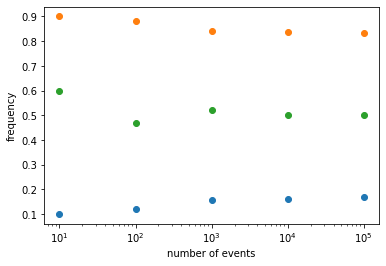

In [5]:
fig, ax = plt.subplots()
plt.scatter(data_c[0],data_c[1])
plt.scatter(data_s[0],data_s[1])
plt.scatter(data_n[0],data_n[1])
ax.set_xscale('log', base=10)
ax.set_xlabel('number of events')
ax.set_ylabel('frequency')
plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(xs, ys, zs, marker=m)
#ax.scatter(xs, ys, zs, marker=m)